# Trails-MD tutorial: adaptive sampling to MSM convergence

This notebook walks through the core building blocks of **Trails-MD** with
small, fast, synthetic examples so every plot renders here without running
molecular dynamics:

1. The **input file** that configures a run
2. **VAMP-2 feature selection**
3. **MSM estimation** (timescales, metastable states)
4. **Convergence detection**
5. **Weighted-ensemble** resampling
6. The **analysis report** utilities

To run a *real* campaign, write an input file (`trails-md-init`) and launch
`trails-md --config config.yaml --iterations 200`. See the docs for details.


In [1]:
import warnings, numpy as np, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
np.random.seed(0)


## 1. The input file

A single YAML file describes a whole run. `trails-md-init` writes an annotated
template; here we load it and validate it against the schema.

In [2]:
import yaml
from trails_md.templates import DEFAULT_TEMPLATE
from trails_md.config import TrailsMDConfig

cfg = TrailsMDConfig(**yaml.safe_load(DEFAULT_TEMPLATE))
print("space_mode      :", cfg.space_mode)
print("spawn_scheme    :", cfg.spawning.spawn_scheme)
print("CV hyperparams  :", cfg.adaptive_model.latent_dim, "dims, lag",
      cfg.adaptive_model.lagtime)
print("execution       :", cfg.execution.backend)
print("msm.enabled     :", cfg.msm.enabled)
print(DEFAULT_TEMPLATE[:380])


space_mode      : vampnet
spawn_scheme    : density
CV hyperparams  : 2 dims, lag 5
execution       : local
msm.enabled     : False
# ============================================================================
# Trails-MD input file
#
# A single YAML file fully describes a run: the system, MD engine, how walkers
# are spawned, the collective-variable (CV) space, optional feature selection
# and MSM-convergence, and where jobs execute. Paths are resolved relative to
# this file. Validate before running:  


## 2. VAMP-2 feature selection

VAMP-2 scores how well a feature set resolves the slow dynamics. Here one
feature carries a slow two-state signal and the rest are noise; selection should
prefer the informative feature.

VAMP-2 ranking: [('slow feature', 0.432), ('noise features', 0.001)]
greedy selection keeps columns: [0]


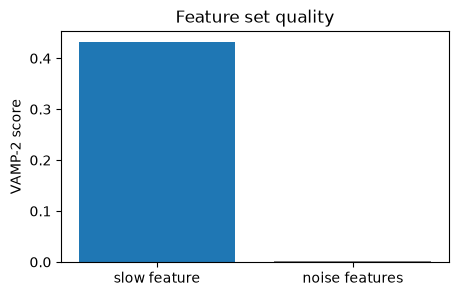

In [3]:
from trails_md.spaces.feature_selection import (
    vamp2_score, rank_candidates, greedy_vamp_selection)

def slow_plus_noise(n=8000, p=0.02, n_noise=4, seed=0):
    rng = np.random.default_rng(seed)
    s, states = 0, np.empty(n, int)
    for i in range(n):
        if rng.random() < p: s = 1 - s
        states[i] = s
    slow = np.where(states==0, -1.0, 1.0) + rng.normal(scale=0.1, size=n)
    return np.column_stack([slow, rng.normal(size=(n, n_noise))])

traj = slow_plus_noise()
ranked = rank_candidates(
    {"slow feature": [traj[:, [0]]], "noise features": [traj[:, 1:]]}, lagtime=10)
print("VAMP-2 ranking:", [(n, round(s,3)) for n,s in ranked])
cols = greedy_vamp_selection([traj], lagtime=10, min_gain=1e-3)
print("greedy selection keeps columns:", cols)

fig, ax = plt.subplots(figsize=(5,3))
ax.bar([n for n,_ in ranked], [s for _,s in ranked], color=["C0","C7"])
ax.set_ylabel("VAMP-2 score"); ax.set_title("Feature set quality"); plt.show()


## 3. MSM estimation

We generate a 3-state metastable chain, build an MSM, and inspect the implied
timescales and metastable free energies.

In [4]:
from trails_md.msm import MSMEstimator

def three_state(n=40000, p=0.02, seed=0):
    rng = np.random.default_rng(seed)
    centers = np.array([-2.0, 0.0, 2.0])
    P = np.array([[1-p, p, 0],[p, 1-2*p, p],[0, p, 1-p]])
    s, states = 0, np.empty(n, int)
    for i in range(n):
        s = rng.choice(3, p=P[s]); states[i] = s
    return (centers[states] + rng.normal(scale=0.15, size=n)).reshape(-1,1)

est = MSMEstimator(lagtime=5, n_microstates=50, n_metastable=3,
                   n_timescales=2, lagtimes=[1,2,5,10,20])
result = est.fit([three_state()])
print(result.summary())
print("stationary distribution:", np.round(result.stationary_distribution, 3))


MSM(lag=5, active_states=50/50, t2..=50.8, 16.6, VAMP2=2.429)
stationary distribution: [0.03  0.018 0.032 0.033 0.02  0.026 0.026 0.021 0.032 0.003 0.015 0.01
 0.014 0.011 0.004 0.037 0.027 0.022 0.01  0.029 0.027 0.031 0.002 0.022
 0.006 0.002 0.016 0.023 0.035 0.022 0.01  0.005 0.027 0.03  0.037 0.029
 0.004 0.02  0.029 0.028 0.029 0.006 0.033 0.015 0.017 0.011 0.008 0.025
 0.029 0.002]


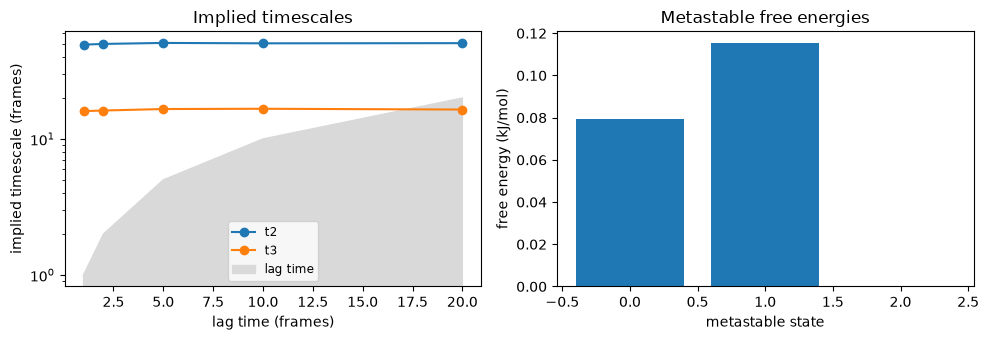

In [5]:
from trails_md.analysis import plots
fig, axes = plt.subplots(1, 2, figsize=(10,3.5))
plots.plot_implied_timescales(result.its.lagtimes, result.its.timescales, ax=axes[0])
plots.plot_metastable_free_energy(result.metastable_populations, ax=axes[1])
plt.tight_layout(); plt.show()


## 4. Convergence detection

A `ConvergenceMonitor` combines criteria (here: implied-timescale stability) and
reports convergence once they hold for `patience` consecutive iterations.

In [6]:
from trails_md.msm import ConvergenceMonitor, ImpliedTimescaleCriterion, MSMResult

def fake(ts):
    return MSMResult(lagtime=5, n_microstates=10, n_states_active=3,
        timescales=np.array([ts]), stationary_distribution=np.ones(3)/3,
        transition_matrix=np.eye(3), cluster_centers=np.zeros((3,1)),
        counts_per_state=np.ones(3))

mon = ConvergenceMonitor([ImpliedTimescaleCriterion(tol=0.05, n_timescales=1)],
                         mode="all", patience=2)
for ts in [100, 102, 101.5, 101.7]:
    print(f"timescale={ts:6.1f} -> converged={mon.update(fake(ts))}")


timescale= 100.0 -> converged=False
timescale= 102.0 -> converged=False
timescale= 101.5 -> converged=True
timescale= 101.7 -> converged=True


## 5. Weighted-ensemble resampling

Split/merge resampling keeps a target walker count per bin while **conserving
total statistical weight**. Below, an under-populated bin (1 walker) is split
and an over-populated bin (4 walkers) is merged.

input total weight : 2.0
output total weight: 2.0
walkers per bin    : [3 3]


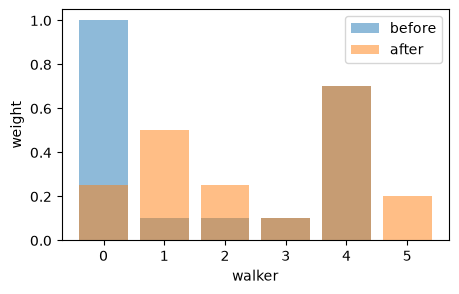

In [7]:
from trails_md.binning.we import WeightedEnsemble
we = WeightedEnsemble(target_per_bin=3)
weights = np.array([1.0, 0.1, 0.1, 0.1, 0.7])
labels  = np.array([0,   1,   1,   1,   1])   # bin 0: 1 walker, bin 1: 4 walkers
res = we.resample(weights, labels, rng=np.random.default_rng(0))
print("input total weight :", weights.sum())
print("output total weight:", round(sum(res.weights), 6))
print("walkers per bin    :", np.bincount(labels[np.array(res.parents)]))

fig, ax = plt.subplots(figsize=(5,3))
ax.bar(range(len(weights)), weights, alpha=.5, label="before")
ax.bar(range(len(res.weights)), res.weights, alpha=.5, label="after")
ax.set_xlabel("walker"); ax.set_ylabel("weight"); ax.legend(); plt.show()


## 6. The analysis report

During a real run each iteration writes an `iter_*/msm.npz`. `trails-md-analyze`
(or `plots.plot_convergence_report`) turns these into a multi-panel summary.
Here we synthesise a small run directory and render the report inline.

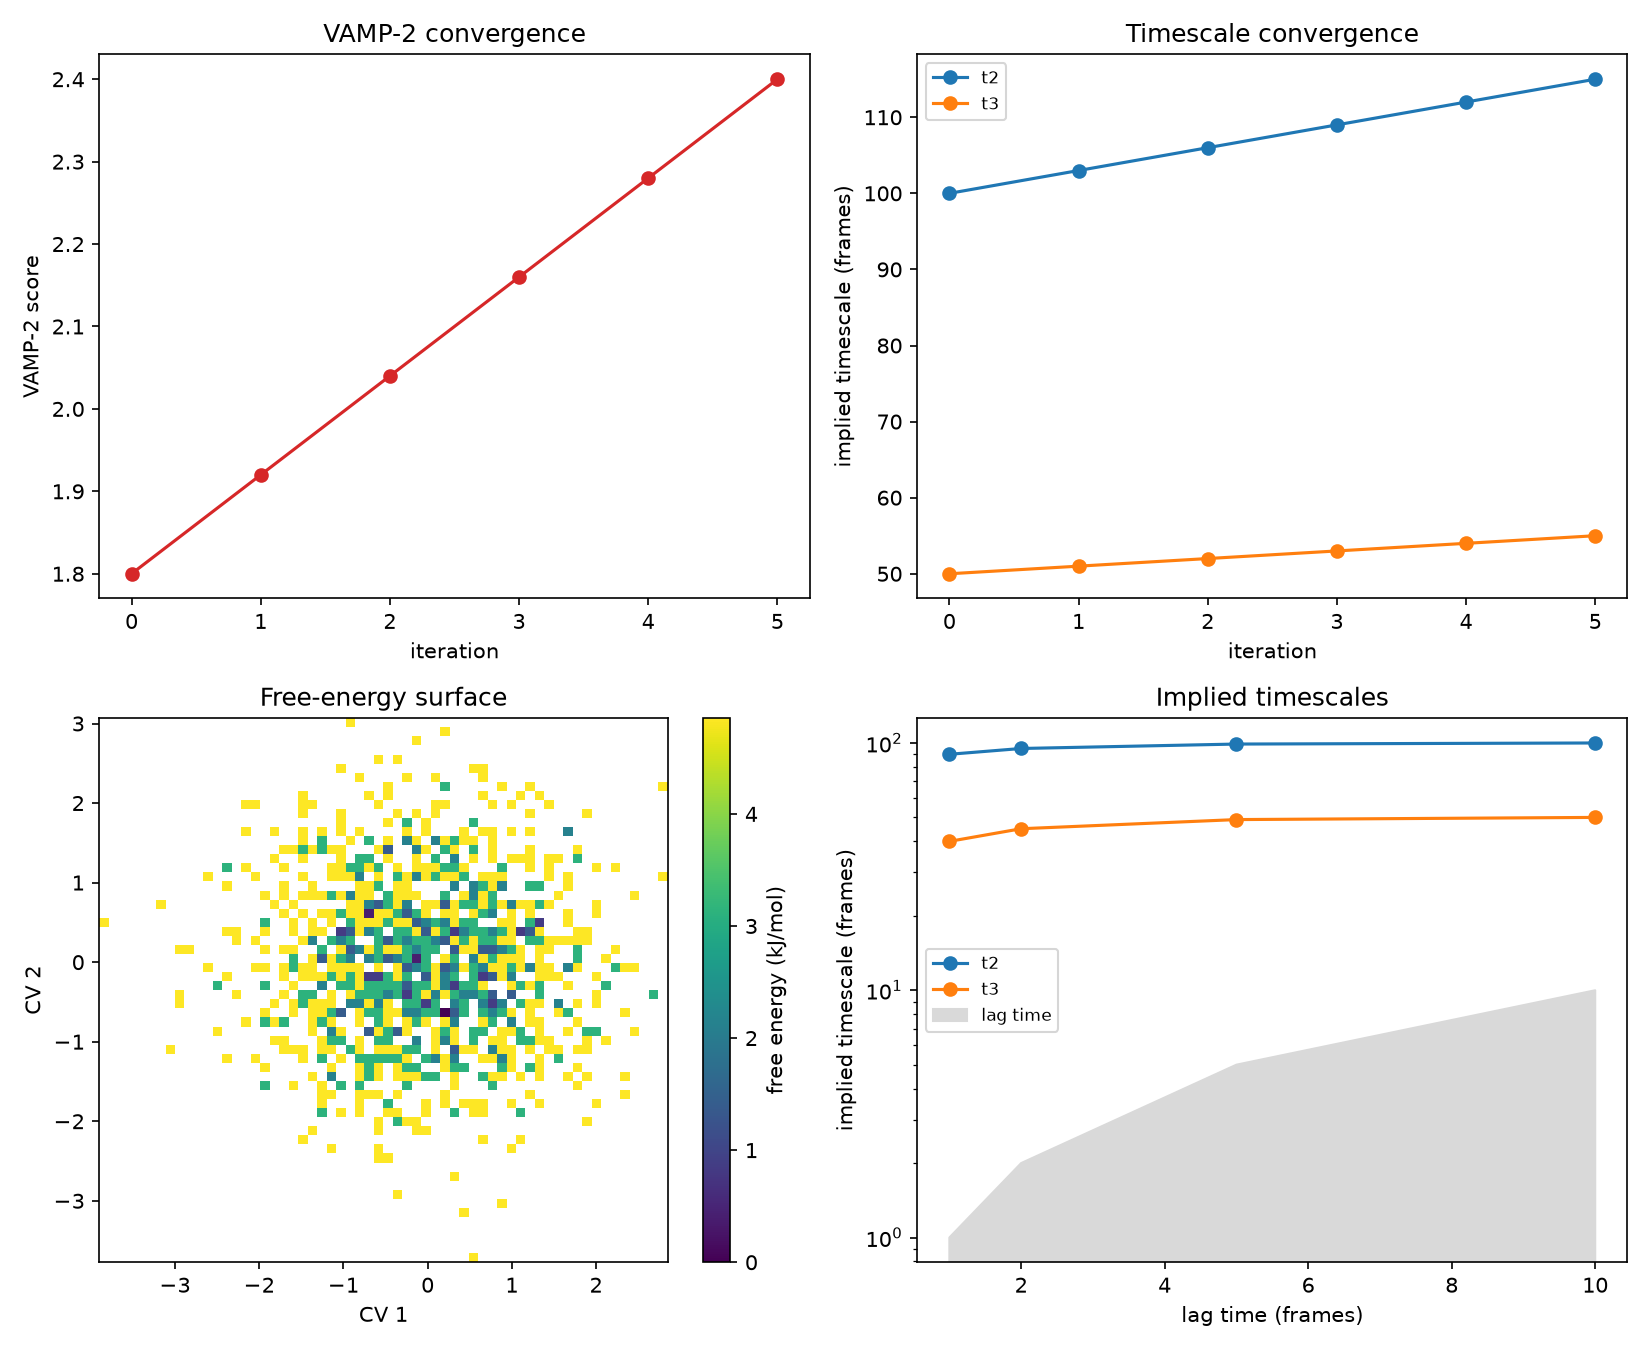

In [8]:
import tempfile
from pathlib import Path
from trails_md.analysis import plots

run = Path(tempfile.mkdtemp())
rng = np.random.default_rng(0)
for it in range(6):
    d = run / f"iter_{it}"; d.mkdir()
    np.savez_compressed(d/"msm.npz",
        lagtime=np.asarray(10),
        timescales=np.array([100.0+it*3, 50.0+it]),
        stationary_distribution=np.array([0.5,0.3,0.2]),
        transition_matrix=np.array([[.9,.08,.02],[.05,.9,.05],[.02,.08,.9]]),
        cluster_centers=np.zeros((3,2)),
        vamp2_score=np.array([1.8+0.12*it]),
        metastable_populations=np.array([0.6,0.4]),
        its_lagtimes=np.array([1.,2.,5.,10.]),
        its_timescales=np.array([[90,40],[95,45],[99,49],[100,50]], float))
    np.savez_compressed(d/"cvs.npz", cvs=rng.normal(size=(200,2)))

out = plots.plot_convergence_report(run)
from IPython.display import Image
Image(filename=str(out))


## 7. Running a real campaign

```bash
trails-md-init -o config.yaml          # write & edit the input file
trails-md --config config.yaml --check # validate
trails-md --config config.yaml --iterations 200
trails-md-analyze --run-dir runs/my_run
```

Switch `execution.backend` to `slurm` or `pbs` to scale out on a cluster — no
other changes needed. See the documentation for the full reference.